In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [6]:
df = pd.read_csv("student_admission_record_dirty.csv")
df.head()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN


In [7]:
df.shape

(157, 7)

In [9]:
df.columns

Index(['Name', 'Age', 'Gender', 'Admission Test Score',
       'High School Percentage', 'City', 'Admission Status'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


In [11]:
df.describe()

,Age,Admission Test Score,High School Percentage
count,147.000000,146.000000,146.000000
mean,19.680272,77.657534,75.684726
std,4.540512,16.855343,17.368014
min,-1.000000,-5.000000,-10.000000
25%,18.000000,68.250000,65.052500
50%,20.000000,79.000000,77.545000
75%,22.000000,89.000000,88.312500
max,24.000000,150.000000,110.500000


In [12]:
df.isnull().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(6)

In [14]:
df_before = df.copy()

In [15]:
df = df.drop_duplicates()

In [19]:
df = df.drop_duplicates().copy()

In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.loc[:, 'Age'] = df['Age'].fillna(df['Age'].median())
df.loc[:, 'Admission Test Score'] = df['Admission Test Score'].fillna(df['Admission Test Score'].median())
df.loc[:, 'High School Percentage'] = df['High School Percentage'].fillna(df['High School Percentage'].median())

In [23]:
df.isnull().sum()

Name                      10
Age                        0
Gender                    10
Admission Test Score       0
High School Percentage     0
City                      10
Admission Status          10
dtype: int64

In [24]:
df.loc[:, 'Name'] = df['Name'].fillna('Unknown')
df.loc[:, 'Gender'] = df['Gender'].fillna('Unknown')
df.loc[:, 'City'] = df['City'].fillna('Unknown')
df.loc[:, 'Admission Status'] = df['Admission Status'].fillna('Unknown')

In [28]:
## Missing Values Before Cleaning
df_before.isnull().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [27]:
## Missing Values After Cleaning
df.isnull().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

## The dataset initially contained missing values across both numerical and categorical columns, as well as duplicate records. These issues can negatively affect the accuracy of analysis and visualizations.

## First, duplicate rows were identified and removed to prevent repeated data from biasing the results.

## For numerical columns such as Age, Admission Test Score, and High School Percentage, missing values were replaced using the median. The median was chosen because it is less affected by extreme values and provides a more stable representation of the data.

## For categorical columns including Name, Gender, City, and Admission Status, missing values were replaced with “Unknown” to preserve the structure of the dataset without introducing incorrect assumptions.

## After cleaning, all missing values were successfully handled, and the dataset became consistent and ready for analysis.

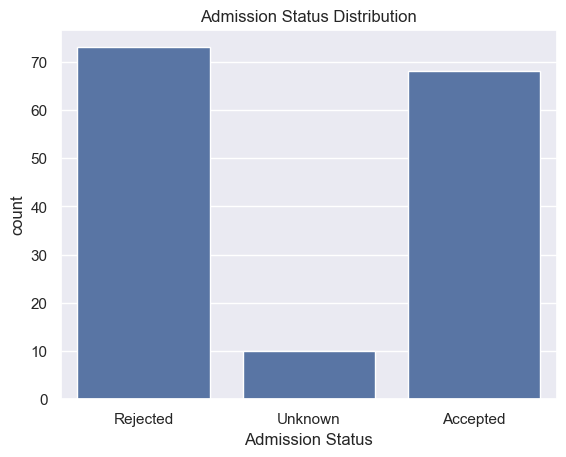

In [29]:
sns.countplot(x='Admission Status', data=df)
plt.title('Admission Status Distribution')
plt.show()

## This chart shows the distribution of accepted and rejected students, helping to understand the overall admission outcome.
    

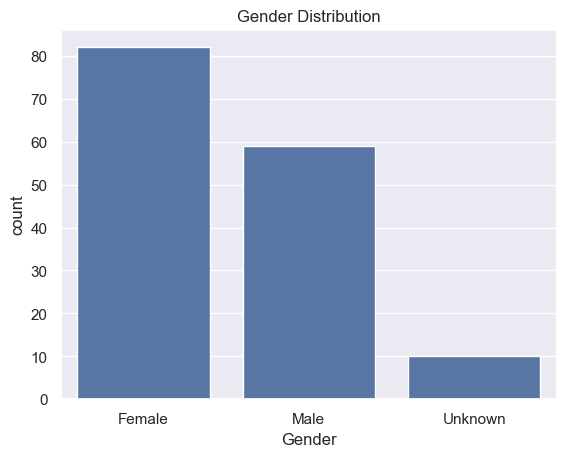

In [30]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

## This visualization shows the proportion of male and female applicants in the dataset.

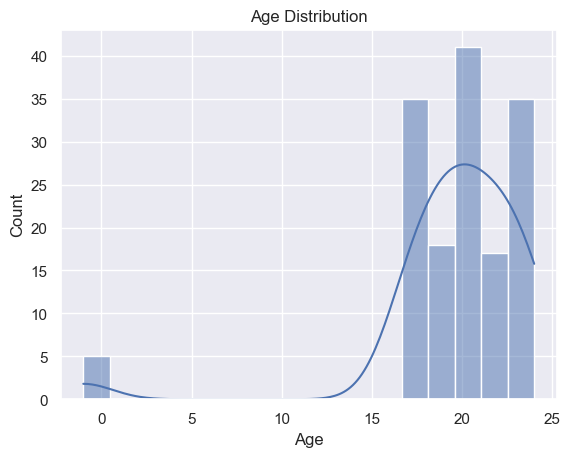

In [31]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

## Most students fall within a specific age range, indicating a consistent applicant demographic.

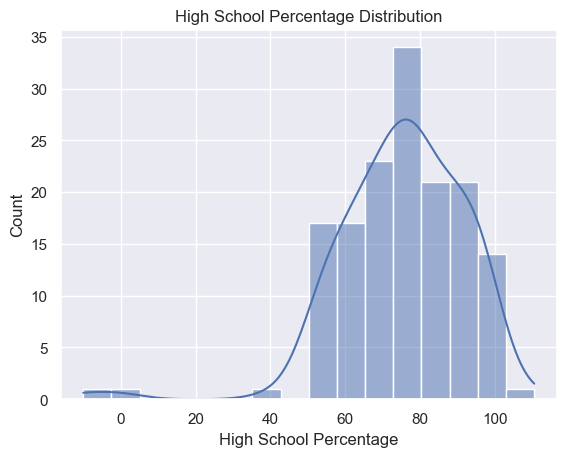

In [32]:
sns.histplot(df['High School Percentage'], kde=True)
plt.title('High School Percentage Distribution')
plt.show()

## This chart shows how previous academic performance is distributed among students.

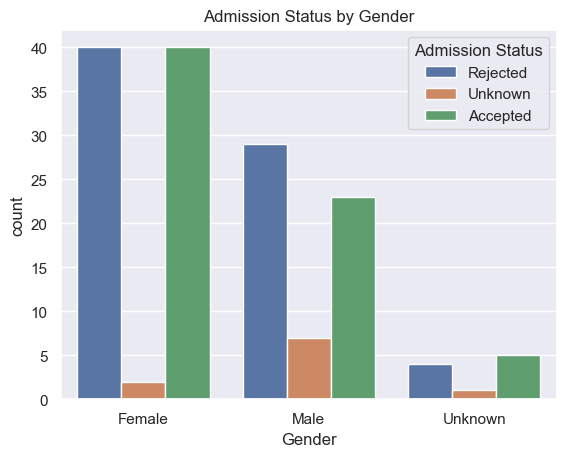

In [33]:
sns.countplot(x='Gender', hue='Admission Status', data=df)
plt.title('Admission Status by Gender')
plt.show()

## This comparison shows whether admission outcomes differ between genders.

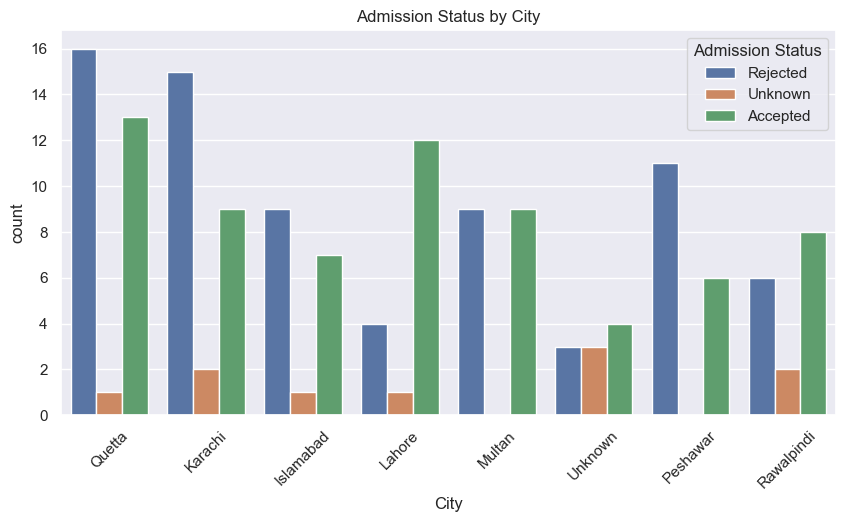

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(x='City', hue='Admission Status', data=df)
plt.xticks(rotation=45)
plt.title('Admission Status by City')
plt.show()

## Some cities have higher numbers of accepted students, suggesting possible regional differences.

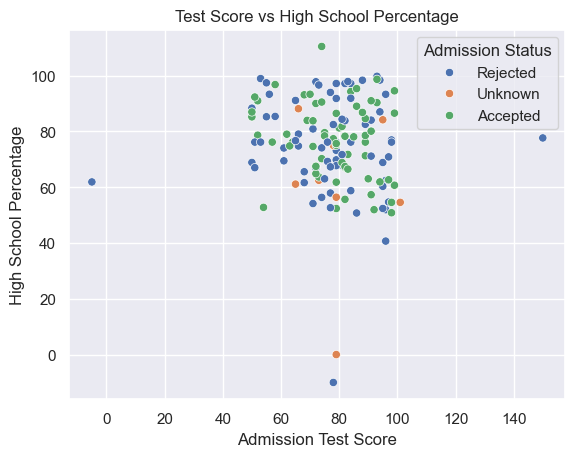

In [35]:
sns.scatterplot(x='Admission Test Score', y='High School Percentage',
                hue='Admission Status', data=df)
plt.title('Test Score vs High School Percentage')
plt.show()

## Students with higher test scores and percentages are more likely to be accepted, indicating a positive relationship.

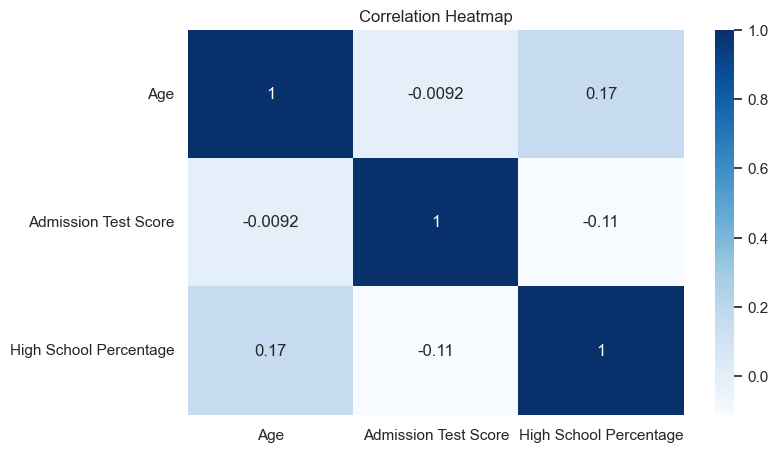

In [36]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Age','Admission Test Score','High School Percentage']].corr(),
            annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

## There is a noticeable correlation between academic variables, especially test scores and high school percentage.

## The exploratory data analysis revealed several important patterns in the dataset. Academic performance appears to play a key role in admission outcomes, as students with higher admission test scores and higher high school percentages are more likely to be accepted.

## The distribution of students across cities shows that some locations contribute more applicants than others, which may influence admission trends. Additionally, the dataset provides insights into demographic factors such as gender and age, although these factors appear less influential compared to academic performance.

## The relationship between admission test scores and high school percentages suggests a positive correlation, indicating that students who perform well academically tend to maintain consistent performance.

## Overall, the analysis highlights that academic metrics are the most significant factors in determining admission decisions. **

In [37]:
df_before.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
5,Murtaza,23.0,Female,NaN,NaN,Islamabad,Accepted
6,Asad,18.0,Male,NaN,97.31,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
8,Rohail,17.0,Male,64.0,NaN,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected


In [38]:
df.head(10)


,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.900,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.730,Karachi,Unknown
2,Bushra,17.0,Male,89.0,76.195,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.290,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.130,Lahore,Unknown
5,Murtaza,23.0,Female,79.0,76.195,Islamabad,Accepted
6,Asad,18.0,Male,79.0,97.310,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.670,Lahore,Accepted
8,Rohail,17.0,Male,64.0,76.195,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.980,Multan,Rejected
